In [83]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time

IMAGE_PATH = 'data/asa.JPG'

# 每執行一次方法就累積一筆，重跑此格會清空紀錄
records = []


def log_run(name, ms, gray):
    records.append({'method': name, 'ms': ms, 'shape': gray.shape, 'mean': gray.mean()})
    print(f'{name:<6s} 執行時間: {ms:8.3f} ms | 尺寸: {gray.shape} | 平均灰階: {gray.mean():.2f}')

## NumPy 實作灰階轉換

依照 ITU-R BT.601 標準，加權公式：

$$\text{Gray} = 0.299 \times R + 0.587 \times G + 0.114 \times B$$


NumPy  執行時間:   43.052 ms | 尺寸: (2048, 946) | 平均灰階: 132.78


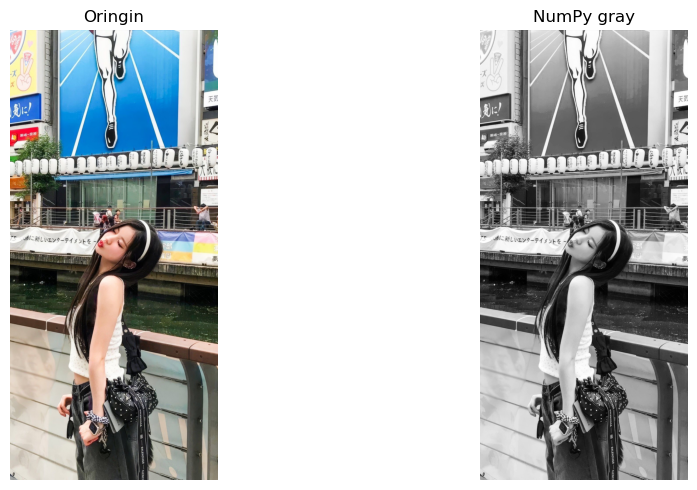

In [80]:
img_rgb = plt.imread(IMAGE_PATH)

weights = np.array([0.299, 0.587, 0.114],dtype=np.float32)

t0 = time.perf_counter()
gray_float = np.dot(img_rgb.astype(np.float32), weights)
gray_numpy = np.clip(np.round(gray_float), 0, 255).astype(np.uint8)
numpy_ms = (time.perf_counter() - t0) * 1000
log_run('NumPy', numpy_ms, gray_numpy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Oringin')
axes[0].axis('off')
axes[1].imshow(gray_numpy, cmap='gray')
axes[1].set_title('NumPy gray')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## OpenCV 灰階轉換

OpenCV 以 BGR 順序讀取影像，`cv2.COLOR_BGR2GRAY` 底層為 C++ 實作。


OpenCV 執行時間:    1.631 ms | 尺寸: (2048, 946) | 平均灰階: 132.78


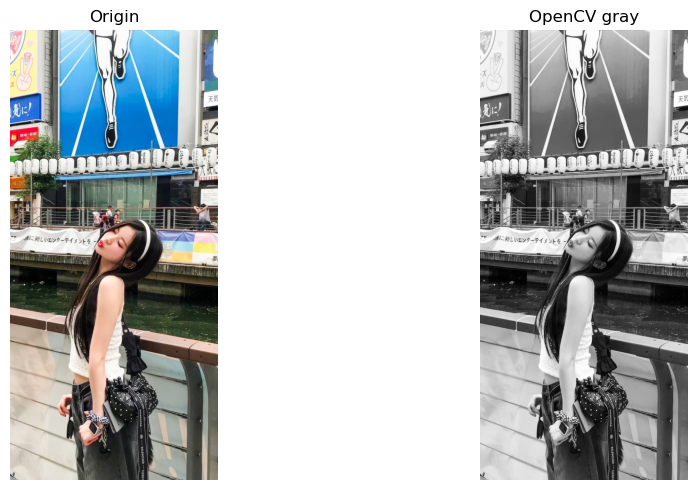

In [81]:
img_bgr = cv2.imread(IMAGE_PATH)

t0 = time.perf_counter()
gray_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
opencv_ms = (time.perf_counter() - t0) * 1000
log_run('OpenCV', opencv_ms, gray_cv)

img_rgb_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb_cv)
axes[0].set_title('Origin')
axes[0].axis('off')
axes[1].imshow(gray_cv, cmap='gray')
axes[1].set_title('OpenCV gray')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 比較執行速度與轉換結果


=== 執行紀錄 ===
 1. NumPy    43.052 ms | 平均灰階: 132.78
 2. OpenCV    1.631 ms | 平均灰階: 132.78

=== 各方法平均 ===
NumPy    43.052 ms (共 1 次)
OpenCV    1.631 ms (共 1 次)


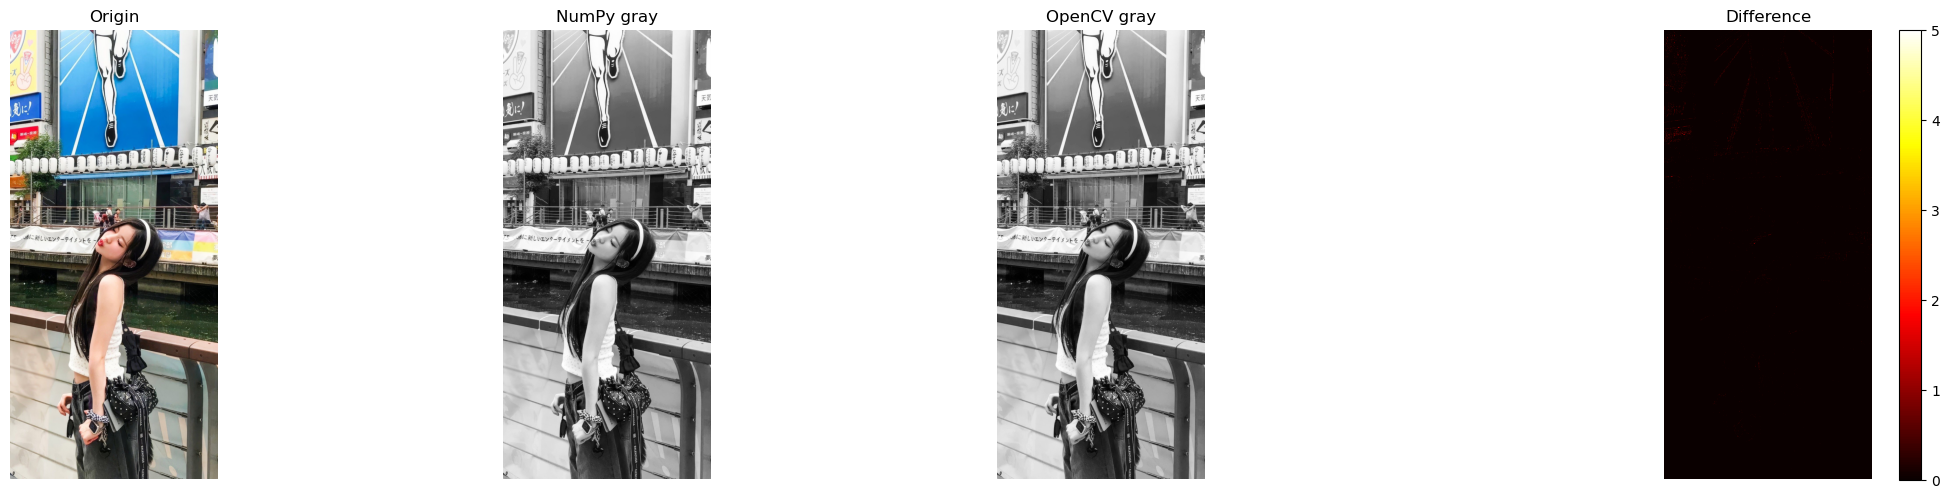

In [82]:
# --- 歷次執行紀錄 ---
print('=== 執行紀錄 ===')
for i, r in enumerate(records, 1):
    print(f"{i:2d}. {r['method']:<6s} {r['ms']:8.3f} ms | 平均灰階: {r['mean']:.2f}")

print('\n=== 各方法平均 ===')
for name in ('NumPy', 'OpenCV'):
    ms_list = [r['ms'] for r in records if r['method'] == name]
    if ms_list:
        print(f'{name:<6s} {sum(ms_list) / len(ms_list):8.3f} ms (共 {len(ms_list)} 次)')

# --- 轉換結果比較 ---
diff = np.abs(gray_numpy.astype(int) - gray_cv.astype(int))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Origin')
axes[0].axis('off')
axes[1].imshow(gray_numpy, cmap='gray')
axes[1].set_title('NumPy gray')
axes[1].axis('off')
axes[2].imshow(gray_cv, cmap='gray')
axes[2].set_title('OpenCV gray')
axes[2].axis('off')
im = axes[3].imshow(diff, cmap='hot', vmin=0, vmax=5)
axes[3].set_title('Difference')
axes[3].axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()